# ROS03 - Click a Goal, Drive There  (LeKiwi - ROS2 - Demo 1)

### Lab Description

With **your** map built (ROS01/ROS02), this is the simplest autonomous navigation: the robot localizes in your map, you click a destination in **RViz**, and **Nav2** plans a path and drives the omni-directional LeKiwi there. Below we define and run the two pieces that connect Nav2 to the hardware: the **omni-wheel kinematics** (how a `/cmd_vel` twist becomes three wheel speeds) and the **odometry integration** (how the wheels become the `/odom` pose Nav2 tracks) - the latter on **your** recorded drive.

#### Recommended Hardware
**LeKiwi** omni-directional base (3x Feetech STS3215 wheels on `/dev/ttyACM0`) + **ZED 2i** stereo camera (USB UVC), driven from an **AMD Ryzen AI** machine (Radeon **gfx1152**, RDNA3.5) - AMD-only, no NVIDIA/CUDA.

#### Software Environment
OS: Ubuntu 24.04 - ROCm 7.13 - PyTorch 2.11 (gfx1152 wheel) - **ROS2 Jazzy** + Nav2 + RTAB-Map - conda env `lerobot-new`. This repo ships **only the LeKiwi ROS2 code** in `lekiwi_ros2/` (repo-relative, so it runs from a clone); it does **not** ship any pre-built map or example run - you produce those yourself on the robot. The `numpy`, `opencv-python`, `pyyaml`, `matplotlib` in `lerobot-new` are enough for the analysis cells. One-time robot setup (the `lerobot-new` env, `bash lekiwi_ros2/utils/setup_raft.sh`, `bash lekiwi_ros2/utils/get_calibration.sh <ZED serial>`) is in `lekiwi_ros2/README.md`.

## Goals
- Bring up the navigation stack: base driver + ZED depth + RTAB-Map localization + Nav2 + RViz
- Define and run the 3-wheel omni (kiwi) mixing that turns /cmd_vel into wheel speeds
- Define and run the dead-reckoning that turns wheel velocities into the /odom pose (on YOUR odom.txt)
- Understand localization vs mapping and why the robot must start at the map origin

> **How this notebook works.** Following the MT06 pattern, each key step is a runnable code cell that **defines the function** doing the work and then runs it. The scene-specific cells read **your own** data - the map *you* build (`utils/scene_map.*`), *your* recorded session (`demo0/rec/...`), *your* `odom.txt` - so **every student's result is different**. Before you have produced that data those cells print a short 'run the robot step first' hint (no canned example is shown). The steps that need the physical robot (camera, motors, ROS2) are `bash` commands you run on the LeKiwi; the full implementations live in `lekiwi_ros2/`.

In [1]:
import os, math, glob, configparser
import numpy as np, cv2, yaml
import matplotlib.pyplot as plt

# This repo ships only the LeKiwi ROS2 code (no pre-built map). You produce the map + data.
ROS2  = os.path.abspath("lekiwi_ros2")
UTILS = f"{ROS2}/utils"
print("repo ROS2 folder:", ROS2)

FREE, OCC, UNKNOWN = 254, 0, 205        # ROS map_server PGM pixel values (white / black / grey)
BLOCK_RGB = {"red": "#e53935", "green": "#43a047", "blue": "#1e88e5", "purple": "#8e24aa"}

def latest_session():
    """Newest recording YOU produced (demo0 manual or demo0-v2 auto). None until you record."""
    recs = sorted(glob.glob(f"{ROS2}/demo0/rec/map*") + glob.glob(f"{ROS2}/demo0-v2/rec/map*"))
    return recs[-1] if recs else None

def have_map(name="scene_map"):
    return os.path.exists(f"{UTILS}/{name}.pgm") and os.path.exists(f"{UTILS}/{name}.yaml")

def load_map(name="scene_map"):
    """Load the occupancy grid YOU built (build_map.sh writes it into utils/). Returns
    (grid, res, ox, oy) with grid[gy, gx], gy increasing upward (the ROS map frame)."""
    m = yaml.safe_load(open(f"{UTILS}/{name}.yaml"))
    res, (ox, oy, _) = m["resolution"], m["origin"]
    with open(f"{UTILS}/{m['image']}", "rb") as f:
        assert f.readline().split()[0] == b"P5"
        t = []
        while len(t) < 3:
            t += f.readline().split(b"#")[0].split()
        W, H = int(t[0]), int(t[1])
        raw = np.frombuffer(f.read(W * H), np.uint8).reshape(H, W)
    return np.ascontiguousarray(np.flipud(raw)), res, ox, oy

def new_map_ax(grid, res, ox, oy, title="", figsize=(6, 5)):
    """Show a grid in metric map-frame coordinates and return the Axes for metric overlays."""
    H, W = grid.shape
    ax = plt.subplots(figsize=figsize)[1]
    ax.imshow(grid, cmap="gray", vmin=0, vmax=255, origin="lower",
              extent=[ox, ox + W * res, oy, oy + H * res])
    ax.set_title(title); ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)"); ax.set_aspect("equal")
    return ax

def load_waypoints():
    """The colour-block positions YOUR build_map.sh saved: {colour: (x, y)} in the map frame."""
    d = {}
    for ln in open(f"{UTILS}/block_waypoints.txt"):
        c, x, y = ln.split(); d[c] = (float(x), float(y))
    return d

def show_my_map():
    """Show the map YOU built, with your block waypoints. Hints if you have not built one yet."""
    if not have_map():
        print("No map yet. Build YOUR map first (run ROS01 or ROS02 on the robot), then re-run.")
        return
    grid, res, ox, oy = load_map()
    ax = new_map_ax(grid, res, ox, oy, "YOUR scene_map")
    if os.path.exists(f"{UTILS}/block_waypoints.txt"):
        for c, (x, y) in load_waypoints().items():
            ax.scatter(x, y, c=BLOCK_RGB.get(c, "orange"), s=90, ec="k", zorder=5, label=c)
        ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

repo ROS2 folder: /home/aup/aup-teaching-labs/projects/Physical-AI/Real-Deployment/ROS2-Deployment/lekiwi_ros2


## Prerequisite - your map

You need **your** `utils/scene_map.*` + `~/.ros/rtabmap.db` from ROS01/ROS02, and the robot at the map **origin**. Confirm your map is here (this is what the demo localizes in and navigates):

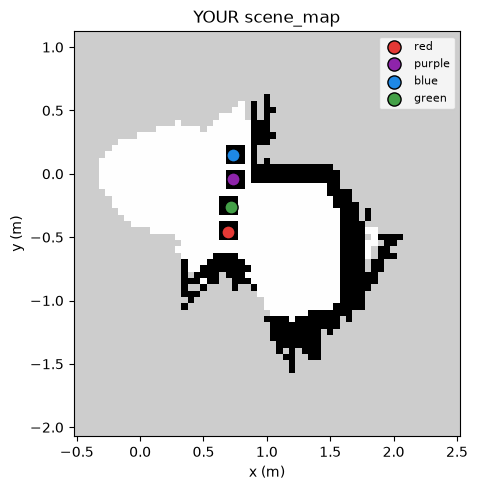

In [5]:
show_my_map()

## Run it on the robot (one command)

`demo1_click_nav.sh` brings up base driver + ZED depth + RTAB-Map **localization** + Nav2 + RViz. Then in RViz: click **Nav2 Goal**, click a **white (free)** point, drag the heading, release - the LeKiwi drives there. `Ctrl-C` stops and auto-cleans.

```bash
bash lekiwi_ros2/demo1/demo1_click_nav.sh
```

## How /cmd_vel becomes wheel speeds

Nav2 outputs a `/cmd_vel` **twist** (`vx, vy` m/s forward/left, `wz` rad/s). The LeKiwi has three omni wheels 120 apart, so any twist maps to three wheel speeds by a fixed mixing - the same principle `lekiwi_base_ros.py` uses via `LeKiwi._body_to_wheel_raw`. Define it and see how forward / strafe / rotate each split across the wheels:

In [3]:
WHEEL_DEG = {"left": 300, "back": 180, "right": 60}   # wheel mount angles around the base

def body_to_wheel(vx, vy, wz, base_radius=0.125):
    """3-wheel omni (kiwi) mixing: body twist (vx, vy m/s, wz rad/s) -> tangential speed
    of each wheel. Same principle as LeKiwi._body_to_wheel_raw on the real motors."""
    out = {}
    for name, deg in WHEEL_DEG.items():
        a = math.radians(deg)
        out[name] = -math.sin(a) * vx + math.cos(a) * vy + base_radius * wz
    return out

for label, twist in {"forward": (0.10, 0, 0), "strafe-left": (0, 0.10, 0),
                     "rotate-CCW": (0, 0, 1.0)}.items():
    w = body_to_wheel(*twist)
    print(f"{label:12s} -> " + "  ".join(f"{k}={v:+.3f}" for k, v in w.items()))

forward      -> left=+0.087  back=-0.000  right=-0.087
strafe-left  -> left=+0.050  back=-0.100  right=+0.050
rotate-CCW   -> left=+0.125  back=+0.125  right=+0.125


## How the wheels become the /odom pose

Going the other way, the base driver reads the wheel-encoder velocities, converts them back to a body twist, and **integrates** it into the pose it publishes as `/odom` + the `odom->base_link` TF. That dead-reckoning is a few lines; the cell runs it on **your** recorded `odom.txt` and overlays it on your recorded path (or a synthetic drive until you have recorded):

YOUR driven path from demo0/rec/map20260721_142129/odom.txt


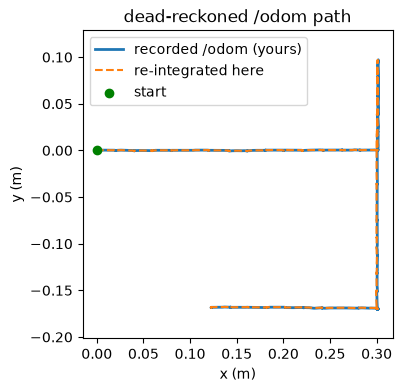

In [4]:
def integrate_odometry(twists, dt=0.1):
    """Dead-reckon a pose from body twists (vx, vy, wz) - exactly how lekiwi_base_ros.py
    turns wheel-encoder velocities into the /odom pose. Returns the (x, y) path."""
    x = y = th = 0.0; xs = [0.0]; ys = [0.0]
    for vx, vy, wz in twists:
        x += (vx*math.cos(th) - vy*math.sin(th)) * dt
        y += (vx*math.sin(th) + vy*math.cos(th)) * dt
        th += wz * dt
        xs.append(x); ys.append(y)
    return np.array(xs), np.array(ys)

sess = latest_session()
odo = f"{sess}/odom.txt" if sess else None
plt.figure(figsize=(4, 4))
if odo and os.path.exists(odo):
    t, x, y, th, vx, vy, vth = np.loadtxt(odo, comments="#").T   # YOUR recorded drive
    xs, ys = integrate_odometry(list(zip(vx, vy, vth)), dt=float(np.median(np.diff(t))))
    plt.plot(x, y, "-", lw=2, label="recorded /odom (yours)")
    plt.plot(xs, ys, "--", label="re-integrated here")
    print("YOUR driven path from", os.path.relpath(odo, ROS2))
else:
    twists = [(0.2, 0, 0)] * 30 + [(0.2, 0, 0.6)] * 30   # no recording yet: synthetic drive
    xs, ys = integrate_odometry(twists)
    plt.plot(xs, ys, "-o", ms=2, label="synthetic (record to see YOURS)")
    print("no recording yet - synthetic path")
plt.scatter([0], [0], c="g", zorder=5, label="start"); plt.axis("equal"); plt.legend()
plt.title("dead-reckoned /odom path"); plt.xlabel("x (m)"); plt.ylabel("y (m)"); plt.show()

## Localization, and why the origin matters

**Mapping** builds a map; **localization** loads it and continuously estimates the robot's pose within it (RTAB-Map matches live features + wheel odom to the stored graph and publishes `map->odom`). `demo1_click_nav.sh` seeds this at **identity** - it assumes the robot is exactly at the origin where mapping started:

```bash
ros2 topic pub -1 /rtabmap/initialpose geometry_msgs/msg/PoseWithCovarianceStamped \
  "{header: {frame_id: map}, pose: {pose: {orientation: {w: 1.0}}}}"
```

Start elsewhere and the whole map is shifted, so goals land in the wrong place - which is why you **mark the origin on the floor**. Because wheel odometry (the integration above) drifts, this visual localization is what keeps the pose honest over a run.

**Your result** is your LeKiwi driving to the goals you click in RViz; screen-record the RViz session if you want to keep it.

## Conclusions

You defined the two bridges between Nav2 and the hardware - `body_to_wheel` (twist -> three omni wheels) and `integrate_odometry` (wheels -> `/odom` pose, run on **your** recorded drive) - and brought up RTAB-Map localization + Nav2 to drive by clicking goals. Nav2 does the global plan + local obstacle avoidance; odometry drift makes short, nearby goals most reliable. Next: **ROS04** computes the goal automatically to reach a named coloured block.

## Acknowledgements

Built on the open-source **LeKiwi** base (Hugging Face **LeRobot**), **RAFT-Stereo** (Princeton), **RTAB-Map**, and **Nav2** on **ROS2 Jazzy**, all running on AMD ROCm (gfx1152) with no NVIDIA/CUDA.

---

Copyright (C) 2026 Advanced Micro Devices, Inc. All rights reserved. Portions of this file consist of AI-generated content.
SPDX-License-Identifier: MIT